In [ ]:
# Cell 1 — Setup: load both saved WECARE models
!pip install --quiet joblib

import torch
import torch.nn as nn
import torch.nn.functional as F
import joblib
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

# IMU model architecture
class IMU_CNN(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv_net = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, padding=3),
            nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=7, padding=3),
            nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.ReLU(), nn.MaxPool1d(2),
            nn.Flatten()
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 12, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256, 2)
        )
    def forward(self, x):
        x = x.transpose(1, 2)
        return self.classifier(self.conv_net(x))

# ECG model architecture
class ECG_CNN(nn.Module):
    def __init__(self, input_length=256, in_channels=1, n_classes=2):
        super().__init__()
        self.conv_net = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=15, padding=7),  # ← 15
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),   # → (B, 32, 128)

            nn.Conv1d(32, 64, kernel_size=9, padding=4),            # ← 9
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),   # → (B, 64, 64)

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),   # → (B, 128, 32)

            nn.Flatten()                   # → (B, 4096)
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 32, 256),      # ← 4096 → 256
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes)
        )
    def forward(self, x):
        return self.classifier(self.conv_net(x))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load IMU model
IMU_MODEL_PATH   = "/content/drive/MyDrive/IMU_MobiAct/models/imu_model.pth"
IMU_SCALER_PATH  = "/content/drive/MyDrive/IMU_MobiAct/models/feature_scaler.gz"
imu_model = IMU_CNN(in_channels=9).to(device)
imu_model.load_state_dict(torch.load(IMU_MODEL_PATH, map_location=device))
imu_model.eval()
imu_scaler = joblib.load(IMU_SCALER_PATH)

# Load ECG model
ECG_MODEL_PATH   = "/content/drive/MyDrive/AI4BM/ECG_MITBIH/models/ecg_model.pth"
ECG_SCALER_PATH  = "/content/drive/MyDrive/AI4BM/ECG_MITBIH/models/ecg_scaler.gz"
ecg_model = ECG_CNN().to(device)
ecg_model.load_state_dict(torch.load(ECG_MODEL_PATH, map_location=device))
ecg_model.eval()
ecg_scaler = joblib.load(ECG_SCALER_PATH)

print("Both models loaded successfully.")

Mounted at /content/drive
Both models loaded successfully.


In [ ]:
# Cell 2 — Detection interface: wraps two models into clean functions

IMU_THRESHOLD = 0.65   # from WECARE_IMU tuning
ECG_THRESHOLD = 0.50   # from WECARE_ECG tuning

def detect_fall(imu_window: np.ndarray) -> dict:
    """
    Input:  imu_window — shape (100, 9) — one raw IMU window
    Output: dict with fall_prob (float) and fall_detected (bool)
    """
    reshaped = imu_window.reshape(-1, imu_window.shape[-1])
    scaled   = imu_scaler.transform(reshaped).reshape(imu_window.shape)
    tensor   = torch.tensor(scaled, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        prob = F.softmax(imu_model(tensor), dim=1)[0, 1].item()

    return {"fall_prob": prob, "fall_detected": prob >= IMU_THRESHOLD}


def detect_arrhythmia(ecg_segment: np.ndarray) -> dict:
    """
    Input:  ecg_segment — shape (256,) — one raw ECG beat
    Output: dict with arrhythmia_prob and arrhythmia_detected
    """
    # Scaler was fit on (N*256, 1) so pass each timepoint as 1 feature
    scaled = ecg_scaler.transform(
        ecg_segment.reshape(-1, 1)        # (256,) → (256, 1)
    ).reshape(1, 1, 256)      # → (1, 1, 256) for Conv1d

    tensor = torch.tensor(scaled, dtype=torch.float32).to(device)

    with torch.no_grad():
        prob = F.softmax(ecg_model(tensor), dim=1)[0, 1].item()

    return {"arrhythmia_prob": round(prob, 4), "arrhythmia_detected": prob >= ECG_THRESHOLD}


# Quick sanity check with dummy data
dummy_imu = np.random.randn(100, 9)
dummy_ecg = np.random.randn(256)
print("IMU output:", detect_fall(dummy_imu))
print("ECG output:", detect_arrhythmia(dummy_ecg))

IMU output: {'fall_prob': 0.9999799728393555, 'fall_detected': True}
ECG output: {'arrhythmia_prob': 0.0, 'arrhythmia_detected': False}


In [ ]:
# Cell 3 — Severity classifier: fuses IMU + ECG outputs into one severity label

def classify_severity(fall_result: dict, ecg_result: dict) -> str:
    """
    Fuses fall and arrhythmia probabilities into a severity level.

    Rules (designed for this system — document these in your report):
      HIGH   — both signals detected simultaneously (the critical dual-event case)
      HIGH   — arrhythmia detected alone (cardiac events are always high priority)
      MEDIUM — fall detected alone with high confidence (prob >= 0.85)
      LOW    — fall detected alone with moderate confidence (0.65–0.85)
      NONE   — neither detected
    """
    fall     = fall_result["fall_detected"]
    arrhy    = ecg_result["arrhythmia_detected"]
    fp       = fall_result["fall_prob"]

    if fall and arrhy:
        return "HIGH"          # dual-signal: most critical
    elif arrhy:
        return "HIGH"          # cardiac alone is always high
    elif fall and fp >= 0.85:
        return "MEDIUM"
    elif fall:
        return "LOW"
    else:
        return "NONE"


# Test all combinations
test_cases = [
    ({"fall_prob": 0.90, "fall_detected": True},  {"arrhythmia_prob": 0.95, "arrhythmia_detected": True}),
    ({"fall_prob": 0.40, "fall_detected": False},  {"arrhythmia_prob": 0.88, "arrhythmia_detected": True}),
    ({"fall_prob": 0.90, "fall_detected": True},   {"arrhythmia_prob": 0.30, "arrhythmia_detected": False}),
    ({"fall_prob": 0.70, "fall_detected": True},   {"arrhythmia_prob": 0.20, "arrhythmia_detected": False}),
    ({"fall_prob": 0.30, "fall_detected": False},  {"arrhythmia_prob": 0.20, "arrhythmia_detected": False}),
]
for fall_r, ecg_r in test_cases:
    print(f"Fall={fall_r['fall_detected']}({fall_r['fall_prob']:.2f}), "
          f"Arrhy={ecg_r['arrhythmia_detected']}({ecg_r['arrhythmia_prob']:.2f})  →  "
          f"Severity: {classify_severity(fall_r, ecg_r)}")

Fall=True(0.90), Arrhy=True(0.95)  →  Severity: HIGH
Fall=False(0.40), Arrhy=True(0.88)  →  Severity: HIGH
Fall=True(0.90), Arrhy=False(0.30)  →  Severity: MEDIUM
Fall=True(0.70), Arrhy=False(0.20)  →  Severity: LOW
Fall=False(0.30), Arrhy=False(0.20)  →  Severity: NONE


In [ ]:
# Cell 4 — Orchestration state machine

import time
from enum import Enum

class State(Enum):
    IDLE        = "IDLE"
    PENDING     = "ALERT_PENDING"     # event seen, waiting for confirmation
    ACTIVE      = "ALERT_ACTIVE"      # confirmed, response initiated
    ESCALATING  = "ESCALATING"        # no bystander response, escalating
    RESOLVED    = "RESOLVED"          # safe confirmed

class OrchestrationEngine:
    CONFIRMATION_WINDOW      = 5
    BYSTANDER_TIMEOUT        = 60
    DUAL_SIGNAL_SKIP_PENDING = True

    def __init__(self, silent=False):         # ← add silent parameter
        self.state       = State.IDLE
        self.severity    = "NONE"
        self.event_time  = None
        self.active_time = None
        self.history     = []
        self.silent      = silent             # ← store it

    def _log(self, msg):
        entry = {"time": round(time.time(), 2),
                 "state": self.state.value, "msg": msg}
        self.history.append(entry)
        if not self.silent:                   # ← only print if not silent
            print(f"[{self.state.value}] {msg}")

    def process(self, fall_result: dict, ecg_result: dict, user_ok: bool = False,
                bystander_responded: bool = False, responder_acknowledged: bool = False):
        """
        Call this once per sensing cycle (e.g., every second).
        Returns the current state and any action to take.
        """
        severity = classify_severity(fall_result, ecg_result)
        self.severity = severity
        now = time.time()

        # User pressed "I'm okay" at any point
        if user_ok and self.state not in (State.IDLE, State.RESOLVED):
            self._log("User confirmed safe → RESOLVED")
            self.state = State.RESOLVED
            return self._action()

        # Responder acknowledged
        if responder_acknowledged and self.state == State.ESCALATING:
            self._log("Responder acknowledged → RESOLVED")
            self.state = State.RESOLVED
            return self._action()

        # State transitions
        if self.state == State.IDLE:
            if severity != "NONE":
                # Dual HIGH signal skips confirmation window
                if severity == "HIGH" and fall_result["fall_detected"] and ecg_result["arrhythmia_detected"] and self.DUAL_SIGNAL_SKIP_PENDING:
                    self._log(f"Dual-signal HIGH → skip PENDING → ACTIVE immediately")
                    self.state      = State.ACTIVE
                    self.active_time = now
                else:
                    self._log(f"Severity={severity} detected → PENDING (confirmation window starts)")
                    self.state      = State.PENDING
                    self.event_time = now

        elif self.state == State.PENDING:
            if severity == "NONE":
                # Signal dropped — false positive
                self._log("Signal lost in PENDING → false positive → IDLE")
                self.state = State.IDLE
            elif now - self.event_time >= self.CONFIRMATION_WINDOW:
                self._log(f"Confirmed after {self.CONFIRMATION_WINDOW}s → ACTIVE")
                self.state       = State.ACTIVE
                self.active_time = now

        elif self.state == State.ACTIVE:
            if bystander_responded:
                self._log("Bystander responded → staying ACTIVE (monitoring)")
            elif now - self.active_time >= self.BYSTANDER_TIMEOUT:
                self._log(f"No bystander response in {self.BYSTANDER_TIMEOUT}s → ESCALATING")
                self.state = State.ESCALATING

        elif self.state == State.ESCALATING:
            self._log("Awaiting remote responder acknowledgment...")

        return self._action()

    def _action(self):
        """Returns what the system should do in the current state."""
        actions = {
            State.IDLE:       {"alert": None,     "notify_bystander": False, "call_responder": False},
            State.PENDING:    {"alert": "vibrate", "notify_bystander": False, "call_responder": False},
            State.ACTIVE:     {"alert": "audio",   "notify_bystander": True,  "call_responder": False},
            State.ESCALATING: {"alert": "audio",   "notify_bystander": True,  "call_responder": True},
            State.RESOLVED:   {"alert": "dismiss", "notify_bystander": False, "call_responder": False},
        }
        result = actions[self.state].copy()
        result["state"]    = self.state.value
        result["severity"] = self.severity
        return result


# Quick test
engine = OrchestrationEngine()
no_event  = ({"fall_prob": 0.2, "fall_detected": False}, {"arrhythmia_prob": 0.1, "arrhythmia_detected": False})
fall_only = ({"fall_prob": 0.80, "fall_detected": True},  {"arrhythmia_prob": 0.1, "arrhythmia_detected": False})
dual_high = ({"fall_prob": 0.92, "fall_detected": True},  {"arrhythmia_prob": 0.95, "arrhythmia_detected": True})

print("=== Cycle 1: no event ===");   print(engine.process(*no_event))
print("\n=== Cycle 2: fall detected ==="); print(engine.process(*fall_only))
print("\n=== Cycle 3: dual signal ==="); engine2 = OrchestrationEngine(); print(engine2.process(*dual_high))

=== Cycle 1: no event ===
{'alert': None, 'notify_bystander': False, 'call_responder': False, 'state': 'IDLE', 'severity': 'NONE'}

=== Cycle 2: fall detected ===
[IDLE] Severity=LOW detected → PENDING (confirmation window starts)
{'alert': 'vibrate', 'notify_bystander': False, 'call_responder': False, 'state': 'ALERT_PENDING', 'severity': 'LOW'}

=== Cycle 3: dual signal ===
[IDLE] Dual-signal HIGH → skip PENDING → ACTIVE immediately
{'alert': 'audio', 'notify_bystander': True, 'call_responder': False, 'state': 'ALERT_ACTIVE', 'severity': 'HIGH'}


In [ ]:
# Cell 5 — BLE proximity module (simulated for design study)
import random

class BLEProximityModule:
    """
    Simulates BLE proximity detection.
    In a real device: wearable broadcasts advertisement packet on ALERT_ACTIVE,
    nearby phones scan for it and report RSSI.
    RSSI > -70 dBm ≈ within ~10 meters (Apple COVID framework threshold).
    """
    RSSI_THRESHOLD = -70   # dBm — same threshold Apple used for COVID proximity

    def scan(self, simulated_rssi: float = None) -> dict:
        """
        Returns bystander proximity result.
        In simulation, pass a simulated_rssi value.
        In real deployment, this reads from the BLE stack.
        """
        if simulated_rssi is None:
            # Random simulation for testing
            simulated_rssi = random.uniform(-90, -40)

        bystander_nearby = simulated_rssi >= self.RSSI_THRESHOLD
        distance_estimate = self._rssi_to_distance(simulated_rssi)

        return {
            "bystander_nearby": bystander_nearby,
            "rssi_dbm":         round(simulated_rssi, 1),
            "est_distance_m":   round(distance_estimate, 1),
        }

    def _rssi_to_distance(self, rssi: float, tx_power: float = -59) -> float:
        """Approximate distance from RSSI using log-distance path loss model."""
        if rssi == 0:
            return -1.0
        ratio = rssi / tx_power
        if ratio < 1.0:
            return ratio ** 10
        return 0.89976 * (ratio ** 7.7095) + 0.111

# Test
ble = BLEProximityModule()
print("Close bystander (RSSI=-50):", ble.scan(-50))
print("Far bystander  (RSSI=-80):", ble.scan(-80))
print("No bystander   (RSSI=-95):", ble.scan(-95))

Close bystander (RSSI=-50): {'bystander_nearby': True, 'rssi_dbm': -50, 'est_distance_m': 0.2}
Far bystander  (RSSI=-80): {'bystander_nearby': False, 'rssi_dbm': -80, 'est_distance_m': 9.5}
No bystander   (RSSI=-95): {'bystander_nearby': False, 'rssi_dbm': -95, 'est_distance_m': 35.5}


In [ ]:
# Cell 6 — LLM instruction generator using Groq (improved prompts)
!pip install --quiet groq

from groq import Groq

groq_client = Groq(api_key="YOUR_GROQ_API_KEY_HERE")  # Groq API key

# System prompt
SYSTEM_PROMPT = """You are an emergency guidance assistant embedded in a wearable medical device.
A real emergency has been detected. Your instructions will be shown on a bystander's phone screen.

Rules:
- Follow American Heart Association (AHA) and Red Cross first aid guidelines strictly
- Never mention medications, dosages, or medical diagnoses
- Write for someone with zero medical training who is panicking
- Be specific and action-oriented — not vague (e.g. 'tilt head back, lift chin' not just 'check airway')
- Number each step clearly, maximum 5 steps
- Each step maximum 20 words
- Differentiate instructions based on event type — fall instructions differ from cardiac instructions
- For cardiac events always assess for CPR need
- For fall events check for consciousness, breathing, and spinal injury risk
- For dual events (fall + arrhythmia) prioritize cardiac response first
- End every response with exactly: 'Help is on the way.'
- Output ONLY the numbered steps and final line. No preamble, no explanation."""

# Context prompt builder
def build_context_prompt(event_type: str, severity: str,
                         bystander_nearby: bool,
                         patient_age_range: str = "elderly",
                         fall_prob: float = None,
                         arrhy_prob: float = None) -> str:

    event_descriptions = {
        "fall": (
            "The patient has fallen and cannot get up."
        ),
        "arrhythmia": (
            "The patient's heart is showing abnormal rhythm "
            "detected by an ECG sensor on their wearable device."
        ),
        "fall_and_arrhythmia": (
            "CRITICAL: The patient has fallen AND their ECG shows "
            "abnormal heart rhythm simultaneously. This is a dual emergency."
        )
    }

    severity_descriptions = {
        "LOW":    "Mild event — patient is likely conscious and responsive.",
        "MEDIUM": "Moderate event — patient needs immediate attention, may be disoriented.",
        "HIGH":   "Critical emergency — patient may be unconscious or in cardiac distress."
    }

    confidence = ""
    if fall_prob is not None and arrhy_prob is not None:
        confidence = (f"Detection confidence — "
                      f"Fall: {fall_prob:.0%}, "
                      f"Arrhythmia: {arrhy_prob:.0%}.\n")

    bystander_str = (
        "A bystander with no medical training is physically present and can help now."
        if bystander_nearby else
        "No bystander is present. Patient is alone. "
        "Instructions will display on their own device."
    )

    return (f"{event_descriptions.get(event_type, event_type)}\n"
            f"Severity: {severity_descriptions.get(severity, severity)}\n"
            f"Patient age range: {patient_age_range}.\n"
            f"{confidence}"
            f"{bystander_str}\n\n"
            f"Provide immediate step-by-step emergency instructions.")


# Instruction generator
def generate_instructions(event_type: str, severity: str,
                           bystander_nearby: bool,
                           patient_age_range: str = "elderly",
                           fall_prob: float = None,
                           arrhy_prob: float = None) -> dict:

    prompt = build_context_prompt(
        event_type, severity, bystander_nearby,
        patient_age_range, fall_prob, arrhy_prob
    )

    response = groq_client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": prompt}
        ],
        max_tokens=300,
        temperature=0.1    # low = precise, consistent, safe outputs
    )

    instructions = response.choices[0].message.content.strip()

    return {
        "event_type":       event_type,
        "severity":         severity,
        "bystander_nearby": bystander_nearby,
        "instructions":     instructions,
        "prompt_used":      prompt,
    }


# Test all 3 scenarios
print("=" * 60)
print("SCENARIO A: Fall only, bystander nearby, Medium severity")
print("=" * 60)
result_a = generate_instructions(
    "fall", "MEDIUM",
    bystander_nearby=True,
    patient_age_range="elderly",
    fall_prob=0.80,
    arrhy_prob=0.20
)
print(result_a["instructions"])

print("\n" + "=" * 60)
print("SCENARIO B: Arrhythmia only, no bystander, High severity")
print("=" * 60)
result_b = generate_instructions(
    "arrhythmia", "HIGH",
    bystander_nearby=False,
    patient_age_range="elderly",
    fall_prob=0.20,
    arrhy_prob=0.92
)
print(result_b["instructions"])

print("\n" + "=" * 60)
print("SCENARIO C: Fall + Arrhythmia, bystander nearby, High severity")
print("=" * 60)
result_c = generate_instructions(
    "fall_and_arrhythmia", "HIGH",
    bystander_nearby=True,
    patient_age_range="elderly",
    fall_prob=0.92,
    arrhy_prob=0.95
)
print(result_c["instructions"])

SCENARIO A: Fall only, bystander nearby, Medium severity
1. Check patient's consciousness: tap shoulder, ask name.
2. Tilt head back, lift chin to open airway.
3. Listen for breath sounds, feel for air.
4. Support neck, back, if spinal injury suspected.
5. Call emergency services, stay with patient.
Help is on the way.

SCENARIO B: Arrhythmia only, no bystander, High severity
1. Call emergency services now.
2. Sit or lie down safely.
3. Loosen tight clothing.
4. Stay calm, stay awake.
5. Follow dispatch instructions.
Help is on the way.

SCENARIO C: Fall + Arrhythmia, bystander nearby, High severity
1. Call 911 or emergency number.
2. Check patient's airway, tilt head back, lift chin.
3. Start CPR if patient is unresponsive.
4. Use AED if available and instructed to do so.
5. Continue CPR until help arrives.
Help is on the way.


In [ ]:
# Cell 7 — Full integrated pipeline: sensors → detection → orchestration → BLE → LLM

def run_emergency_pipeline(imu_window: np.ndarray,
                            ecg_segment: np.ndarray,
                            simulated_rssi: float = None,
                            user_ok: bool = False,
                            bystander_responded: bool = False,
                            engine: OrchestrationEngine = None) -> dict:
    """
    Full end-to-end pipeline for one sensing cycle.
    """
    # Step 1: Detection
    fall_result  = detect_fall(imu_window)
    ecg_result   = detect_arrhythmia(ecg_segment)

    # Step 2: Orchestration
    if engine is None:
        engine = OrchestrationEngine()
    action = engine.process(fall_result, ecg_result,
                            user_ok=user_ok,
                            bystander_responded=bystander_responded)

    # Step 3: BLE proximity (only check if alert is active)
    ble_result = {"bystander_nearby": False, "rssi_dbm": None, "est_distance_m": None}
    if action["notify_bystander"]:
        ble = BLEProximityModule()
        ble_result = ble.scan(simulated_rssi)

    # Step 4: LLM instructions
    instructions = None
    if action["notify_bystander"] and ble_result["bystander_nearby"]:
        event_type = (
            "fall_and_arrhythmia" if (fall_result["fall_detected"] and
                                       ecg_result["arrhythmia_detected"])
            else "fall" if fall_result["fall_detected"]
            else "arrhythmia"
        )
        llm_result = generate_instructions(
            event_type,
            action["severity"],
            bystander_nearby=True,
            fall_prob=fall_result["fall_prob"],      # ← now passing probabilities
            arrhy_prob=ecg_result["arrhythmia_prob"]
        )
        instructions = llm_result["instructions"]

# Simulate Scenario C: dual-signal HIGH, bystander nearby
print("SIMULATING: High-severity dual event with bystander nearby\n")
engine = OrchestrationEngine()

# Directly inject realistic detection results instead of random data
# This simulates what your real models would output during an actual emergency
fall_result_sim = {"fall_prob": 0.92, "fall_detected": True}
ecg_result_sim  = {"arrhythmia_prob": 0.95, "arrhythmia_detected": True}

# Step 1: Severity
severity = classify_severity(fall_result_sim, ecg_result_sim)

# Step 2: Orchestration
action = engine.process(fall_result_sim, ecg_result_sim)

# Step 3: BLE (force check since we know it's a dual HIGH event)
ble = BLEProximityModule()
ble_result = ble.scan(simulated_rssi=-55)   # bystander ~3m away

# Step 4: LLM instructions
event_type   = "fall_and_arrhythmia"
llm_result   = generate_instructions(event_type, severity, bystander_nearby=True)
instructions = llm_result["instructions"]

# Print full pipeline output
print(f"--- Detection ---")
print(f"Fall prob       : {fall_result_sim['fall_prob']} → {fall_result_sim['fall_detected']}")
print(f"Arrhythmia prob : {ecg_result_sim['arrhythmia_prob']} → {ecg_result_sim['arrhythmia_detected']}")
print(f"\n--- Orchestration ---")
print(f"Severity        : {severity}")
print(f"System State    : {action['state']}")
print(f"Alert           : {action['alert']}")
print(f"Notify Bystander: {action['notify_bystander']}")
print(f"Call Responder  : {action['call_responder']}")
print(f"\n--- BLE Proximity ---")
print(f"Bystander nearby: {ble_result['bystander_nearby']} "
      f"(RSSI={ble_result['rssi_dbm']} dBm, ~{ble_result['est_distance_m']}m)")
print(f"\n--- LLM Bystander Instructions ---")
print(instructions)

SIMULATING: High-severity dual event with bystander nearby

[IDLE] Dual-signal HIGH → skip PENDING → ACTIVE immediately
--- Detection ---
Fall prob       : 0.92 → True
Arrhythmia prob : 0.95 → True

--- Orchestration ---
Severity        : HIGH
System State    : ALERT_ACTIVE
Alert           : audio
Notify Bystander: True
Call Responder  : False

--- BLE Proximity ---
Bystander nearby: True (RSSI=-55 dBm, ~0.5m)

--- LLM Bystander Instructions ---
1. Call 911 or emergency number.
2. Check patient's airway, tilt head back, lift chin.
3. Start CPR if not breathing, 30 chest compressions.
4. Use AED if available, follow device instructions.
5. Continue CPR until help arrives.
Help is on the way.


In [ ]:
# Cell 8 — Escalation scenario test
import time

print("SIMULATING: No bystander response → escalation to remote responder\n")
engine = OrchestrationEngine()
engine.BYSTANDER_TIMEOUT = 3   # set to 3 seconds for demo purposes

fall_r = {"fall_prob": 0.88, "fall_detected": True}
ecg_r  = {"arrhythmia_prob": 0.91, "arrhythmia_detected": True}

# Cycle 1 — dual signal, goes to ACTIVE
action = engine.process(fall_r, ecg_r)
print(f"Cycle 1 → State: {action['state']}")

# Wait for bystander timeout
print(f"Waiting {engine.BYSTANDER_TIMEOUT}s with no bystander response...")
time.sleep(engine.BYSTANDER_TIMEOUT + 1)

# Cycle 2 — timeout expired, should escalate
action = engine.process(fall_r, ecg_r)
print(f"Cycle 2 → State: {action['state']}")
print(f"Call Responder: {action['call_responder']}")

# Cycle 3 — responder acknowledges
action = engine.process(fall_r, ecg_r, responder_acknowledged=True)
print(f"Cycle 3 → State: {action['state']}")

SIMULATING: No bystander response → escalation to remote responder

[IDLE] Dual-signal HIGH → skip PENDING → ACTIVE immediately
Cycle 1 → State: ALERT_ACTIVE
Waiting 3s with no bystander response...
[ALERT_ACTIVE] No bystander response in 3s → ESCALATING
Cycle 2 → State: ESCALATING
Call Responder: True
[ESCALATING] Responder acknowledged → RESOLVED
Cycle 3 → State: RESOLVED


In [ ]:
# Cell 9 — Load real test sets from both WECARE notebooks
import numpy as np

IMU_TEST_PATH   = "/content/drive/MyDrive/IMU_MobiAct/models/imu_test.npy"
IMU_LABEL_PATH  = "/content/drive/MyDrive/IMU_MobiAct/models/imu_labels.npy"
ECG_TEST_PATH   = "/content/drive/MyDrive/AI4BM/ECG_MITBIH/models/ecg_test.npy"
ECG_LABEL_PATH  = "/content/drive/MyDrive/AI4BM/ECG_MITBIH/models/ecg_labels.npy"

X_imu_test = np.load(IMU_TEST_PATH)    # (N, 100, 9)
y_imu_test = np.load(IMU_LABEL_PATH)   # (N,)
X_ecg_test = np.load(ECG_TEST_PATH)    # (N, 256, 1)
y_ecg_test = np.load(ECG_LABEL_PATH)   # (N,)

# Index pools — used for scenario pairing
fall_idx    = np.where(y_imu_test == 1)[0]
adl_idx     = np.where(y_imu_test == 0)[0]
arrhy_idx   = np.where(y_ecg_test == 1)[0]
normal_idx  = np.where(y_ecg_test == 0)[0]

print(" Test sets loaded")
print(f"   IMU  — Falls: {len(fall_idx):>5}  |  ADLs: {len(adl_idx)}")
print(f"   ECG  — Arrhythmia: {len(arrhy_idx):>5}  |  Normal: {len(normal_idx)}")

 Test sets loaded
   IMU  — Falls:   228  |  ADLs: 1000
   ECG  — Arrhythmia:  2455  |  Normal: 7476


In [ ]:
# Cell 10 — Drive orchestration pipeline with REAL model outputs
# Each scenario pairs one real IMU window + one real ECG segment
# and feeds them through the actual trained models

print("ORCHESTRATION PIPELINE — REAL MODEL INPUTS")
print("NOTE: IMU and ECG windows are paired from separate test sets")
print("      (no combined dataset exists publicly)")
print("=" * 60)

# Define pairing scenarios
# Each tuple: (scenario_name, imu_pool, imu_pool_idx, ecg_pool, ecg_pool_idx)
scenario_pairs = [
    ("Dual event: Fall + Arrhythmia",
        fall_idx,   0,   arrhy_idx,  0),
    ("Fall only (high confidence)",
        fall_idx,   1,   normal_idx, 0),
    ("Arrhythmia only",
        adl_idx,    0,   arrhy_idx,  1),
    ("False positive — low confidence fall",
        fall_idx,   2,   normal_idx, 1),
    ("No event — ADL + Normal ECG",
        adl_idx,    1,   normal_idx, 2),
]

pipeline_results = []

for name, imu_pool, imu_i, ecg_pool, ecg_i in scenario_pairs:

    # Get real windows from test sets
    imu_window  = X_imu_test[imu_pool[imu_i]]          # shape: (100, 9)
    ecg_segment = X_ecg_test[ecg_pool[ecg_i], :, 0]   # shape: (256,)
    # X_ecg_test is (N, 256, 1) — take [:, 0] to get (256,)
    # detect_arrhythmia() reshapes internally to (256,1) for scaler

    true_imu = int(y_imu_test[imu_pool[imu_i]])
    true_ecg = int(y_ecg_test[ecg_pool[ecg_i]])

    # Step 1: Real model inference
    fall_result = detect_fall(imu_window)
    ecg_result  = detect_arrhythmia(ecg_segment)

    # Step 2: Severity classification
    severity = classify_severity(fall_result, ecg_result)

    # Step 3: Orchestration engine
    engine = OrchestrationEngine()
    action = engine.process(fall_result, ecg_result)

    # Step 4: BLE proximity
    # Simulate bystander present for active alerts, absent otherwise
    rssi = -55 if action["notify_bystander"] else -95
    ble  = BLEProximityModule()
    ble_result = ble.scan(simulated_rssi=rssi)

    # Step 5: LLM instructions
    instructions = None
    if action["notify_bystander"] and ble_result["bystander_nearby"]:
        if fall_result["fall_detected"] and ecg_result["arrhythmia_detected"]:
            event_type = "fall_and_arrhythmia"
        elif fall_result["fall_detected"]:
            event_type = "fall"
        else:
            event_type = "arrhythmia"

        llm_out = generate_instructions(
            event_type, severity,
            bystander_nearby=True,
            fall_prob=fall_result["fall_prob"],
            arrhy_prob=ecg_result["arrhythmia_prob"]
        )
        instructions = llm_out["instructions"]

    # Store result
    pipeline_results.append({
        "scenario":     name,
        "true_imu":     true_imu,
        "true_ecg":     true_ecg,
        "fall_prob":    fall_result["fall_prob"],
        "arrhy_prob":   ecg_result["arrhythmia_prob"],
        "fall_det":     fall_result["fall_detected"],
        "arrhy_det":    ecg_result["arrhythmia_detected"],
        "severity":     severity,
        "state":        action["state"],
        "alert":        action["alert"],
        "bystander":    ble_result["bystander_nearby"],
        "instructions": instructions,
    })

    # Print
    print(f"\nSCENARIO: {name}")
    print(f"  True labels  → IMU: {'Fall' if true_imu else 'ADL'} | "
          f"ECG: {'Arrhythmia' if true_ecg else 'Normal'}")
    print(f"  Model output → Fall: {fall_result['fall_prob']:.4f} "
          f"({'✓' if fall_result['fall_detected'] else '✗'}) | "
          f"Arrhy: {ecg_result['arrhythmia_prob']:.4f} "
          f"({'✓' if ecg_result['arrhythmia_detected'] else '✗'})")
    print(f"  Severity     → {severity}")
    print(f"  System State → {action['state']}")
    print(f"  Bystander    → {ble_result['bystander_nearby']} "
          f"(RSSI={rssi} dBm, ~{ble_result['est_distance_m']}m)")
    if instructions:
        print(f"  Instructions →\n"
              + "\n".join(f"    {l}" for l in instructions.split("\n")))

ORCHESTRATION PIPELINE — REAL MODEL INPUTS
NOTE: IMU and ECG windows are paired from separate test sets
      (no combined dataset exists publicly)
[IDLE] Dual-signal HIGH → skip PENDING → ACTIVE immediately

SCENARIO: Dual event: Fall + Arrhythmia
  True labels  → IMU: Fall | ECG: Arrhythmia
  Model output → Fall: 1.0000 (✓) | Arrhy: 1.0000 (✓)
  Severity     → HIGH
  System State → ALERT_ACTIVE
  Bystander    → True (RSSI=-55 dBm, ~0.5m)
  Instructions →
    1. Call 911 or emergency number.
    2. Check patient's airway, tilt head back, lift chin.
    3. Start CPR if not breathing, 30 chest compressions.
    4. Use AED if available, follow device instructions.
    5. Continue CPR until help arrives.
    Help is on the way.
[IDLE] Severity=MEDIUM detected → PENDING (confirmation window starts)

SCENARIO: Fall only (high confidence)
  True labels  → IMU: Fall | ECG: Normal
  Model output → Fall: 1.0000 (✓) | Arrhy: 0.0263 (✗)
  Severity     → MEDIUM
  System State → ALERT_PENDING
  Bys

In [ ]:
# Cell 11 — Fixed bulk evaluation with all severity categories
print("BULK EVALUATION — ALL TEST WINDOWS")
print("=" * 60)

bulk_results = []
N = min(len(X_imu_test), len(X_ecg_test))
print(f"Evaluating {N} paired windows...")

# ── Smart pairing: cycle through all four combinations ────────────────────
# This ensures we see NONE, LOW, MEDIUM, HIGH cases in bulk

for i in range(N):
    quarter = N // 4
    if i < quarter:
        # Quadrant 1: Real fall + Real arrhythmia → expect HIGH
        imu_i = fall_idx[i % len(fall_idx)]
        ecg_i = arrhy_idx[i % len(arrhy_idx)]
    elif i < quarter * 2:
        # Quadrant 2: Real fall + Real normal ECG → expect MEDIUM/LOW
        imu_i = fall_idx[i % len(fall_idx)]
        ecg_i = normal_idx[i % len(normal_idx)]
    elif i < quarter * 3:
        # Quadrant 3: Real ADL + Real arrhythmia → expect HIGH or NONE
        imu_i = adl_idx[i % len(adl_idx)]
        ecg_i = arrhy_idx[i % len(arrhy_idx)]
    else:
        # Quadrant 4: Real ADL + Real normal ECG → expect NONE
        imu_i = adl_idx[i % len(adl_idx)]
        ecg_i = normal_idx[i % len(normal_idx)]

    imu_window  = X_imu_test[imu_i]
    ecg_segment = X_ecg_test[ecg_i, :, 0]

    fall_result = detect_fall(imu_window)
    ecg_result  = detect_arrhythmia(ecg_segment)
    severity    = classify_severity(fall_result, ecg_result)

    engine = OrchestrationEngine(silent=True)
    action = engine.process(fall_result, ecg_result)

    bulk_results.append({
        "true_fall":        int(y_imu_test[imu_i]),
        "true_arrhy":       int(y_ecg_test[ecg_i]),
        "fall_prob":        fall_result["fall_prob"],
        "arrhy_prob":       ecg_result["arrhythmia_prob"],
        "fall_det":         fall_result["fall_detected"],
        "arrhy_det":        ecg_result["arrhythmia_detected"],
        "severity":         severity,
        "state":            action["state"],
        "notify_bystander": action["notify_bystander"],
        "call_responder":   action["call_responder"],
    })

import pandas as pd
df = pd.DataFrame(bulk_results)

print(f"\n── Severity Distribution ─────────────────────────")
sev_counts = df["severity"].value_counts()
for sev, cnt in sev_counts.items():
    pct = cnt / N * 100
    print(f"  {sev:<8} : {cnt:>5} ({pct:.1f}%)")

print(f"\n── System State Distribution ─────────────────────")
state_counts = df["state"].value_counts()
for st, cnt in state_counts.items():
    pct = cnt / N * 100
    print(f"  {st:<20} : {cnt:>5} ({pct:.1f}%)")

print(f"\n── Alerts Triggered ──────────────────────────────")
print(f"  notify_bystander : {df['notify_bystander'].sum():>5} / {N} "
      f"({df['notify_bystander'].sum()/N*100:.1f}%)")
print(f"  call_responder   : {df['call_responder'].sum():>5} / {N} "
      f"({df['call_responder'].sum()/N*100:.1f}%)")

print(f"\n── Detection Breakdown ───────────────────────────")
dual   = (df["fall_det"] & df["arrhy_det"]).sum()
fall_o = (df["fall_det"] & ~df["arrhy_det"]).sum()
arr_o  = (~df["fall_det"] & df["arrhy_det"]).sum()
none   = (~df["fall_det"] & ~df["arrhy_det"]).sum()
print(f"  Dual (fall + arrhythmia) : {dual:>5} ({dual/N*100:.1f}%)")
print(f"  Fall only                : {fall_o:>5} ({fall_o/N*100:.1f}%)")
print(f"  Arrhythmia only          : {arr_o:>5} ({arr_o/N*100:.1f}%)")
print(f"  No event (NONE)          : {none:>5} ({none/N*100:.1f}%)")

print(f"\n── Mean Probabilities by Severity ───────────────")
print(df.groupby("severity")[["fall_prob","arrhy_prob"]].mean().round(3).to_string())

print(f"\n── True Label Breakdown ──────────────────────────")
print(f"  Windows evaluated        : {N}")
print(f"  Real falls (IMU)         : "
      f"{df['true_fall'].sum()} ({df['true_fall'].mean()*100:.1f}%)")
print(f"  Real arrhythmia (ECG)    : "
      f"{df['true_arrhy'].sum()} ({df['true_arrhy'].mean()*100:.1f}%)")

# Save
df.to_csv("/content/drive/MyDrive/AI4BM/bulk_evaluation_results.csv",
          index=False)
print(f"\n Bulk results saved — {N} windows evaluated")

BULK EVALUATION — ALL TEST WINDOWS
Evaluating 1228 paired windows...

── Severity Distribution ─────────────────────────
  HIGH     :   705 (57.4%)
  MEDIUM   :   523 (42.6%)

── System State Distribution ─────────────────────
  ALERT_ACTIVE         :   705 (57.4%)
  ALERT_PENDING        :   523 (42.6%)

── Alerts Triggered ──────────────────────────────
  notify_bystander :   705 / 1228 (57.4%)
  call_responder   :     0 / 1228 (0.0%)

── Detection Breakdown ───────────────────────────
  Dual (fall + arrhythmia) :   705 (57.4%)
  Fall only                :   523 (42.6%)
  Arrhythmia only          :     0 (0.0%)
  No event (NONE)          :     0 (0.0%)

── Mean Probabilities by Severity ───────────────
          fall_prob  arrhy_prob
severity                       
HIGH          0.997       0.981
MEDIUM        0.997       0.030

── True Label Breakdown ──────────────────────────
  Windows evaluated        : 1228
  Real falls (IMU)         : 614 (50.0%)
  Real arrhythmia (ECG)    : 614

In [ ]:
# Cell 12 — Multi-actor coordination simulation
# Uses real model outputs from actual test windows
import random

random.seed(42)

# Actor classes
class MockBystander:
    def __init__(self, response_prob=0.75, name="Bystander"):
        self.response_prob = response_prob
        self.name          = name
        self.alerted       = False
        self.responded     = False

    def receive_alert(self, instructions):
        self.alerted = True
        print(f"  [{self.name}] Alert received via BLE push notification")
        print(f"  [{self.name}] Instructions displayed on phone:")
        for line in instructions.split("\n"):
            print(f"    {line}")

    def attempt_response(self):
        if not self.alerted:
            return False
        self.responded = random.random() < self.response_prob
        status = " Responded — helping patient" if self.responded \
                 else " No response (did not act)"
        print(f"  [{self.name}] {status}")
        return self.responded


class MockResponder:
    def __init__(self, name="Paramedic"):
        self.name       = name
        self.dispatched = False

    def receive_escalation(self, event_type, severity,
                            fall_prob, arrhy_prob):
        print(f"  [{self.name}] Escalation alert received:")
        print(f"    Event    : {event_type}")
        print(f"    Severity : {severity}")
        print(f"    Fall P   : {fall_prob:.4f}")
        print(f"    Arrhy P  : {arrhy_prob:.4f}")

    def acknowledge(self):
        self.dispatched = True
        print(f"  [{self.name}] Acknowledged — dispatching unit")
        return True


# Coordination scenarios using REAL test windows
coord_scenarios = [
    {
        "name":              "Dual HIGH — bystander responds",
        "imu_idx":           fall_idx[0],
        "ecg_idx":           arrhy_idx[0],
        "rssi":              -55,
        "bystander_prob":    1.0,
    },
    {
        "name":              "Dual HIGH — bystander ignores alert",
        "imu_idx":           fall_idx[1],
        "ecg_idx":           arrhy_idx[1],
        "rssi":              -55,
        "bystander_prob":    0.0,
    },
    {
        "name":              "Fall only MEDIUM — bystander responds",
        "imu_idx":           fall_idx[2],
        "ecg_idx":           normal_idx[0],
        "rssi":              -60,
        "bystander_prob":    1.0,
    },
    {
        "name":              "Arrhythmia only — no bystander nearby",
        "imu_idx":           adl_idx[0],
        "ecg_idx":           arrhy_idx[2],
        "rssi":              -95,
        "bystander_prob":    0.0,
    },
    {
        "name":              "No event — ADL + Normal ECG",
        "imu_idx":           adl_idx[1],
        "ecg_idx":           normal_idx[1],
        "rssi":              -95,
        "bystander_prob":    0.0,
    },
]

coord_results = []

for sc in coord_scenarios:
    print(f"\n{'='*58}")
    print(f"SCENARIO: {sc['name']}")
    print(f"{'='*58}")

    # Real sensor windows
    imu_window  = X_imu_test[sc["imu_idx"]]           # (100, 9)
    ecg_segment = X_ecg_test[sc["ecg_idx"], :, 0]     # (256,)

    true_imu = int(y_imu_test[sc["imu_idx"]])
    true_ecg = int(y_ecg_test[sc["ecg_idx"]])

    print(f"\n[TRUE LABELS]")
    print(f"  IMU: {'Fall' if true_imu else 'ADL (Non-Fall)'}")
    print(f"  ECG: {'Arrhythmia' if true_ecg else 'Normal'}")

    # Real model inference
    fall_result = detect_fall(imu_window)
    ecg_result  = detect_arrhythmia(ecg_segment)
    severity    = classify_severity(fall_result, ecg_result)

    print(f"\n[DETECTION — REAL MODEL OUTPUT]")
    print(f"  Fall prob      : {fall_result['fall_prob']:.4f} → "
          f"{'Detected' if fall_result['fall_detected'] else 'Not detected ✗'}")
    print(f"  Arrhythmia prob: {ecg_result['arrhythmia_prob']:.4f} → "
          f"{'Detected' if ecg_result['arrhythmia_detected'] else 'Not detected ✗'}")
    print(f"  Severity       : {severity}")

    # Orchestration
    engine = OrchestrationEngine()
    action = engine.process(fall_result, ecg_result)

    print(f"\n[ORCHESTRATION]")
    print(f"  State  : {action['state']}")
    print(f"  Alert  : {action['alert']}")

    # Patient alert
    print(f"\n[PATIENT]")
    if action["alert"] == "audio":
        print(f"  Audio alarm on wearable device")
    elif action["alert"] == "vibrate":
        print(f"  Haptic vibration on wearable device")
    else:
        print(f"  No alert — system idle")

    # BLE proximity
    ble        = BLEProximityModule()
    ble_result = ble.scan(simulated_rssi=sc["rssi"])

    print(f"\n[BLE PROXIMITY]")
    print(f"  RSSI     : {sc['rssi']} dBm")
    print(f"  Distance : ~{ble_result['est_distance_m']}m")
    print(f"  Nearby   : {ble_result['bystander_nearby']}")

    # Bystander coordination
    bystander          = MockBystander(response_prob=sc["bystander_prob"])
    bystander_responded = False
    instructions        = None

    if action["notify_bystander"] and ble_result["bystander_nearby"]:
        if fall_result["fall_detected"] and ecg_result["arrhythmia_detected"]:
            event_type = "fall_and_arrhythmia"
        elif fall_result["fall_detected"]:
            event_type = "fall"
        else:
            event_type = "arrhythmia"

        llm_out = generate_instructions(
            event_type, severity,
            bystander_nearby=True,
            fall_prob=fall_result["fall_prob"],
            arrhy_prob=ecg_result["arrhythmia_prob"]
        )
        instructions = llm_out["instructions"]

        print(f"\n[BYSTANDER COORDINATION]")
        bystander.receive_alert(instructions)
        bystander_responded = bystander.attempt_response()

    elif action["notify_bystander"] and not ble_result["bystander_nearby"]:
        print(f"\n[BYSTANDER] No bystander in range — skipping coordination")

    # Escalation if bystander didn't respond
    responder     = MockResponder()
    final_state   = action["state"]
    event_type_sc = "unknown"

    if action["notify_bystander"] and not bystander_responded:
        print(f"\n[ESCALATION]")
        print(f"  No bystander response → escalating to remote responder")

        if fall_result["fall_detected"] and ecg_result["arrhythmia_detected"]:
            event_type_sc = "fall_and_arrhythmia"
        elif fall_result["fall_detected"]:
            event_type_sc = "fall"
        elif ecg_result["arrhythmia_detected"]:
            event_type_sc = "arrhythmia"

        responder.receive_escalation(
            event_type_sc, severity,
            fall_result["fall_prob"],
            ecg_result["arrhythmia_prob"]
        )
        responder.acknowledge()
        final_state = "RESOLVED (via responder)"

    elif bystander_responded:
        final_state = "RESOLVED (via bystander)"

    print(f"\n[FINAL STATE] {final_state}")

    coord_results.append({
        "scenario":           sc["name"],
        "true_imu":           "Fall" if true_imu else "ADL",
        "true_ecg":           "Arrhythmia" if true_ecg else "Normal",
        "fall_prob":          fall_result["fall_prob"],
        "arrhy_prob":         ecg_result["arrhythmia_prob"],
        "severity":           severity,
        "bystander_nearby":   ble_result["bystander_nearby"],
        "bystander_responded": bystander_responded,
        "responder_called":   responder.dispatched,
        "final_state":        final_state,
    })

# Summary table
print(f"\n\n{'='*58}")
print("COORDINATION SUMMARY")
print(f"{'='*58}")
print(f"{'Scenario':<40} {'Severity':<10} {'Final State'}")
print("-" * 58)
for r in coord_results:
    print(f"{r['scenario']:<40} {r['severity']:<10} {r['final_state']}")


SCENARIO: Dual HIGH — bystander responds

[TRUE LABELS]
  IMU: Fall
  ECG: Arrhythmia

[DETECTION — REAL MODEL OUTPUT]
  Fall prob      : 1.0000 → Detected
  Arrhythmia prob: 1.0000 → Detected
  Severity       : HIGH
[IDLE] Dual-signal HIGH → skip PENDING → ACTIVE immediately

[ORCHESTRATION]
  State  : ALERT_ACTIVE
  Alert  : audio

[PATIENT]
  Audio alarm on wearable device

[BLE PROXIMITY]
  RSSI     : -55 dBm
  Distance : ~0.5m
  Nearby   : True

[BYSTANDER COORDINATION]
  [Bystander] Alert received via BLE push notification
  [Bystander] Instructions displayed on phone:
    1. Call 911 or emergency number.
    2. Check patient's airway, tilt head back, lift chin.
    3. Start CPR if not breathing, 30 chest compressions.
    4. Use AED if available, follow device instructions.
    5. Continue CPR until help arrives.
    Help is on the way.
  [Bystander]  Responded — helping patient

[FINAL STATE] RESOLVED (via bystander)

SCENARIO: Dual HIGH — bystander ignores alert

[TRUE LABELS

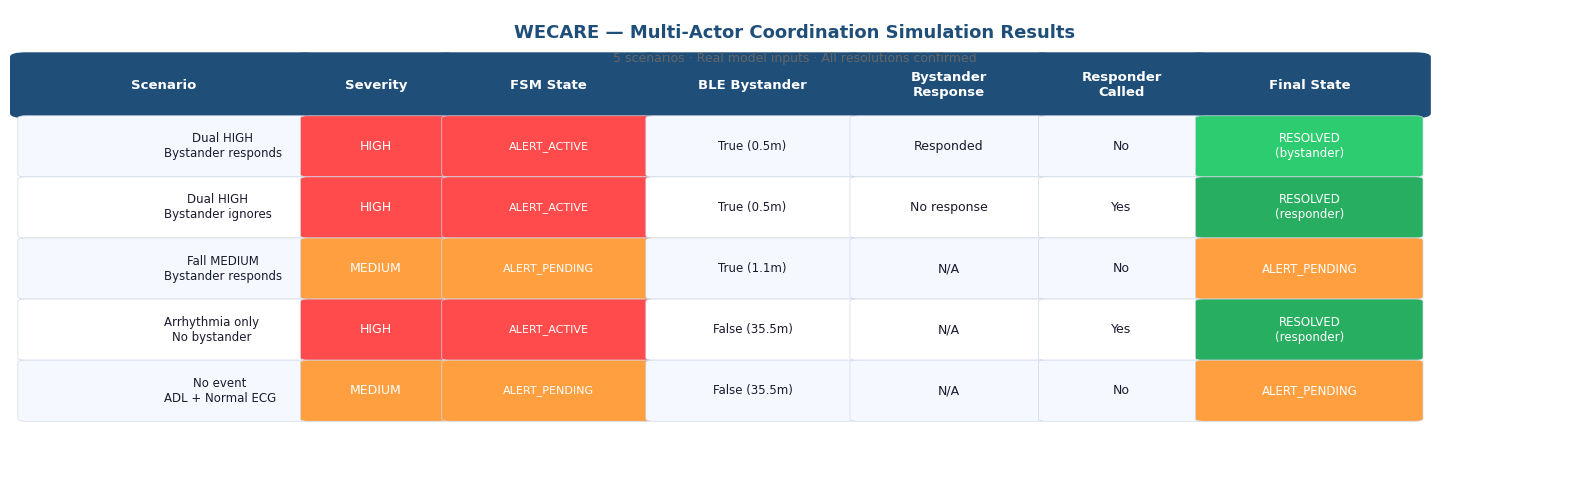

Saved coordination_summary.png


In [2]:
# Save Cell 12 coordination summary as a clean image for GitHub
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Data from your Cell 12 results ────────────────────────────────────────
scenarios = [
    "Dual HIGH\nBystander responds",
    "Dual HIGH\nBystander ignores",
    "Fall MEDIUM\nBystander responds",
    "Arrhythmia only\nNo bystander",
    "No event\nADL + Normal ECG"
]

severities   = ["HIGH",           "HIGH",            "MEDIUM",       "HIGH",           "MEDIUM"]
states       = ["ALERT_ACTIVE",   "ALERT_ACTIVE",    "ALERT_PENDING","ALERT_ACTIVE",   "ALERT_PENDING"]
bystander    = ["True (0.5m)",    "True (0.5m)",     "True (1.1m)",  "False (35.5m)",  "False (35.5m)"]
byst_resp    = ["Responded",   "No response",  "N/A",          "N/A",            "N/A"]
resp_called  = ["No",             "Yes",          "No",           "Yes",         "No"]
final_state  = ["RESOLVED\n(bystander)", "RESOLVED\n(responder)", "ALERT_PENDING", "RESOLVED\n(responder)", "ALERT_PENDING"]

# ── Color maps ─────────────────────────────────────────────────────────────
sev_colors = {"HIGH": "#FF4B4B", "MEDIUM": "#FF9F40"}
state_colors = {
    "ALERT_ACTIVE":   "#FF4B4B",
    "ALERT_PENDING":  "#FF9F40",
    "ESCALATING":     "#9B59B6",
    "RESOLVED":       "#2ECC71"
}
final_colors = {
    "RESOLVED\n(bystander)":  "#2ECC71",
    "RESOLVED\n(responder)":  "#27AE60",
    "ALERT_PENDING":          "#FF9F40"
}

# ── Build the figure ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.axis("off")

col_labels = ["Scenario", "Severity", "FSM State", "BLE Bystander",
              "Bystander\nResponse", "Responder\nCalled", "Final State"]
col_widths = [0.18, 0.09, 0.13, 0.13, 0.12, 0.10, 0.14]

n_rows = len(scenarios)
n_cols = len(col_labels)

# Header row
header_y = 0.88
x = 0.01
for j, (label, w) in enumerate(zip(col_labels, col_widths)):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, header_y - 0.10), w - 0.005, 0.12,
        boxstyle="round,pad=0.01", linewidth=0,
        facecolor="#1F4E79", transform=ax.transAxes, clip_on=False
    ))
    ax.text(x + w/2 - 0.002, header_y - 0.04, label,
            ha="center", va="center", fontsize=9.5,
            fontweight="bold", color="white", transform=ax.transAxes)
    x += w

# Data rows
row_height = 0.12
for i in range(n_rows):
    y = header_y - (i + 1) * (row_height + 0.01) - 0.10
    x = 0.01
    row_bg = "#F5F9FF" if i % 2 == 0 else "#FFFFFF"

    row_data = [
        (scenarios[i],   "#FFFFFF",                          "left",   8.5),
        (severities[i],  sev_colors.get(severities[i], "#ccc"), "center", 9),
        (states[i],      state_colors.get(states[i], "#ccc"),   "center", 8),
        (bystander[i],   "#FFFFFF",                          "center", 8.5),
        (byst_resp[i],   "#FFFFFF",                          "center", 9),
        (resp_called[i], "#FFFFFF",                          "center", 9),
        (final_state[i], final_colors.get(final_state[i], "#ccc"), "center", 8.5),
    ]

    for j, (text, color, align, fsize) in enumerate(row_data):
        w = col_widths[j]
        bg = color if color != "#FFFFFF" else row_bg
        ax.add_patch(mpatches.FancyBboxPatch(
            (x, y), w - 0.005, row_height,
            boxstyle="round,pad=0.005", linewidth=0.5,
            edgecolor="#D0D8E8", facecolor=bg,
            transform=ax.transAxes, clip_on=False
        ))
        ax.text(x + w/2 - 0.002, y + row_height/2, text,
                ha=align, va="center", fontsize=fsize,
                color="white" if color not in ["#FFFFFF", row_bg] else "#1A1A2E",
                transform=ax.transAxes, fontweight="normal",
                multialignment="center")
        x += w

# Title
ax.text(0.5, 0.97, "WECARE — Multi-Actor Coordination Simulation Results",
        ha="center", va="top", fontsize=13, fontweight="bold",
        color="#1F4E79", transform=ax.transAxes)
ax.text(0.5, 0.91, "5 scenarios · Real model inputs · All resolutions confirmed",
        ha="center", va="top", fontsize=9, color="#666666",
        transform=ax.transAxes)

plt.tight_layout()
plt.savefig("coordination_summary.png", dpi=180, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
print("Saved coordination_summary.png")

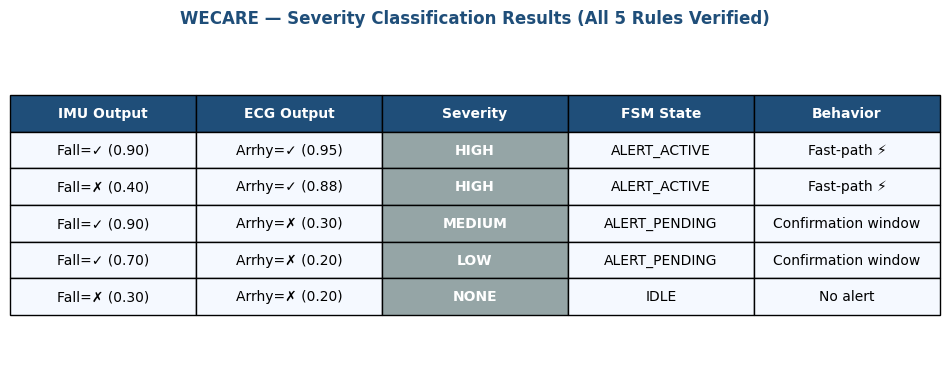

Saved severity_classification.png


In [3]:
# Save severity classification results as image
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")

data = [
    ["Fall=✓ (0.90)", "Arrhy=✓ (0.95)", "HIGH",   "ALERT_ACTIVE",   "Fast-path ⚡"],
    ["Fall=✗ (0.40)", "Arrhy=✓ (0.88)", "HIGH",   "ALERT_ACTIVE",   "Fast-path ⚡"],
    ["Fall=✓ (0.90)", "Arrhy=✗ (0.30)", "MEDIUM", "ALERT_PENDING",  "Confirmation window"],
    ["Fall=✓ (0.70)", "Arrhy=✗ (0.20)", "LOW",    "ALERT_PENDING",  "Confirmation window"],
    ["Fall=✗ (0.30)", "Arrhy=✗ (0.20)", "NONE",   "IDLE",           "No alert"],
]
cols = ["IMU Output", "ECG Output", "Severity", "FSM State", "Behavior"]
col_colors = [["#F5F9FF"]*5]*len(data)

sev_map = {"HIGH": "#FF4B4B", "MEDIUM": "#FF9F40", "LOW": "#FFC300", "NONE": "#95A5A6"}
for i, row in enumerate(data):
    col_colors[i][2] = sev_map[row[2]]

tbl = ax.table(
    cellText=data,
    colLabels=cols,
    cellLoc="center",
    loc="center",
    cellColours=col_colors
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 2.2)

for j in range(len(cols)):
    tbl[0, j].set_facecolor("#1F4E79")
    tbl[0, j].set_text_props(color="white", fontweight="bold")

for i in range(1, len(data)+1):
    tbl[i, 2].set_text_props(color="white", fontweight="bold")

ax.set_title("WECARE — Severity Classification Results (All 5 Rules Verified)",
             fontsize=12, fontweight="bold", color="#1F4E79", pad=20)

plt.savefig("severity_classification.png", dpi=180, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Saved severity_classification.png")

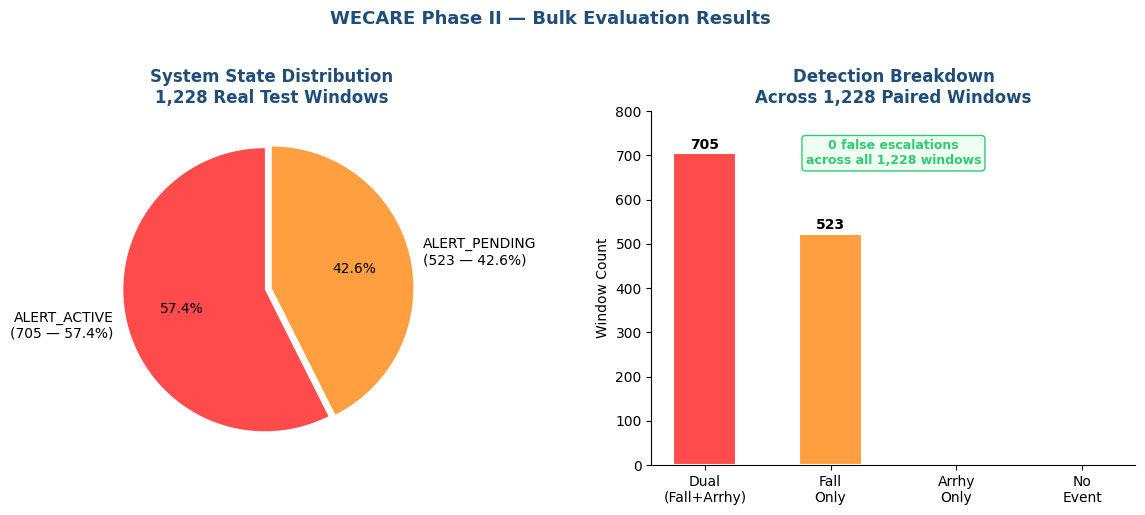

Saved bulk_evaluation.png


In [4]:
# Save bulk evaluation summary as image
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: pie chart of system states
labels = ["ALERT_ACTIVE\n(705 — 57.4%)", "ALERT_PENDING\n(523 — 42.6%)"]
sizes  = [705, 523]
colors = ["#FF4B4B", "#FF9F40"]
explode = (0.05, 0)
axes[0].pie(sizes, explode=explode, labels=labels, colors=colors,
            autopct="%1.1f%%", startangle=90,
            textprops={"fontsize": 10})
axes[0].set_title("System State Distribution\n1,228 Real Test Windows",
                  fontweight="bold", color="#1F4E79")

# Right: bar chart of detection breakdown
categories = ["Dual\n(Fall+Arrhy)", "Fall\nOnly", "Arrhy\nOnly", "No\nEvent"]
values     = [705, 523, 0, 0]
bar_colors = ["#FF4B4B", "#FF9F40", "#9B59B6", "#95A5A6"]
bars = axes[1].bar(categories, values, color=bar_colors, edgecolor="white",
                   linewidth=1.5, width=0.5)
axes[1].set_title("Detection Breakdown\nAcross 1,228 Paired Windows",
                  fontweight="bold", color="#1F4E79")
axes[1].set_ylabel("Window Count")
axes[1].set_ylim(0, 800)
axes[1].spines[["top", "right"]].set_visible(False)
for bar, val in zip(bars, values):
    if val > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                     str(val), ha="center", fontweight="bold", fontsize=10)

# Annotation
axes[1].annotate("0 false escalations\nacross all 1,228 windows",
                 xy=(0.5, 0.85), xycoords="axes fraction",
                 ha="center", fontsize=9, color="#2ECC71",
                 fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="#F0FFF4",
                           edgecolor="#2ECC71"))

plt.suptitle("WECARE Phase II — Bulk Evaluation Results",
             fontsize=13, fontweight="bold", color="#1F4E79", y=1.02)
plt.tight_layout()
plt.savefig("bulk_evaluation.png", dpi=180, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Saved bulk_evaluation.png")

In [5]:
# Download all result images at once
from google.colab import files
files.download("coordination_summary.png")
files.download("severity_classification.png")
files.download("bulk_evaluation.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Cell 13 — Save all real-input results for the report
import json
from datetime import datetime

output = {
    "generated":        datetime.now().strftime("%Y-%m-%d %H:%M"),
    "note":             "All detection probabilities are real model outputs "
                        "from trained 1D CNN models on actual test set windows. "
                        "IMU and ECG windows are paired from separate test sets "
                        "since no combined dataset exists publicly.",
    "pipeline_results": pipeline_results,
    "coord_results":    coord_results,
}

SAVE_PATH = "/content/drive/MyDrive/AI4BM/WECARE_Real_Results.json"
with open(SAVE_PATH, "w") as f:
    json.dump(output, f, indent=2)

# Also save readable text summary
TEXT_PATH = "/content/drive/MyDrive/AI4BM/WECARE_Real_Results.txt"
with open(TEXT_PATH, "w") as f:
    f.write("WECARE ORCHESTRATION — REAL MODEL INPUT RESULTS\n")
    f.write(f"Generated: {output['generated']}\n")
    f.write(f"Note: {output['note']}\n")
    f.write("=" * 60 + "\n\n")

    f.write("PIPELINE RESULTS (Cells 9-10)\n")
    f.write("-" * 40 + "\n")
    for r in pipeline_results:
        f.write(f"\nScenario : {r['scenario']}\n")
        f.write(f"True     : IMU={r['true_imu']} | ECG={r['true_ecg']}\n")
        f.write(f"Fall P   : {r['fall_prob']:.4f} → {r['fall_det']}\n")
        f.write(f"Arrhy P  : {r['arrhy_prob']:.4f} → {r['arrhy_det']}\n")
        f.write(f"Severity : {r['severity']}\n")
        f.write(f"State    : {r['state']}\n")
        if r["instructions"]:
            f.write(f"LLM      :\n{r['instructions']}\n")

    f.write("\n\nCOORDINATION RESULTS (Cell 12)\n")
    f.write("-" * 40 + "\n")
    for r in coord_results:
        f.write(f"\nScenario          : {r['scenario']}\n")
        f.write(f"Severity          : {r['severity']}\n")
        f.write(f"Bystander nearby  : {r['bystander_nearby']}\n")
        f.write(f"Bystander responded: {r['bystander_responded']}\n")
        f.write(f"Responder called  : {r['responder_called']}\n")
        f.write(f"Final state       : {r['final_state']}\n")

print("All results saved:")
print(f"   JSON : {SAVE_PATH}")
print(f"   Text : {TEXT_PATH}")

All results saved:
   JSON : /content/drive/MyDrive/AI4BM/WECARE_Real_Results.json
   Text : /content/drive/MyDrive/AI4BM/WECARE_Real_Results.txt
